In [1]:
!pip install haiqu-sdk --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.0/57.0 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.0/664.0 kB 25.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.3/167.3 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 93.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 104.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 96.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 106.3 MB/s e

In [2]:
from google.colab import files
uploaded = files.upload()  # відкриється вікно — вибери qnn_trained_params.json і qnn_test_samples.json

Saving qnn_test_samples.json to qnn_test_samples (1).json
Saving qnn_trained_params.json to qnn_trained_params (1).json


In [4]:
import haiqu
print("Haiqu SDK імпортовано успішно")
print(dir(haiqu))  # покаже, що взагалі є всередині пакету

import os
print("\nВсі JSON-файли в Colab:", [f for f in os.listdir() if f.endswith(".json")])

Haiqu SDK імпортовано успішно
['__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__']

Всі JSON-файли в Colab: ['qnn_trained_params (1).json', 'qnn_trained_params.json', 'qnn_test_samples.json', 'qnn_test_samples (1).json']


In [6]:
import json
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Operator
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, classification_report

with open("qnn_trained_params.json") as f:
    params = json.load(f)
with open("qnn_test_samples.json") as f:
    test_data = json.load(f)

weights = np.array(params["weights"])       # форма (2, 1, 8, 3)
readout_w = np.array(params["readout_w"])   # форма (8,)
readout_b = params["readout_b"]
n_qubits = params["n_qubits"]
n_reuploads = params["n_reuploads"]

X_test = np.array(test_data["X_test"])
y_test = np.array(test_data["y_test"])

print(f"Кубітів: {n_qubits}, re-uploads: {n_reuploads}")
print(f"Тестових пацієнтів: {len(X_test)}")

Кубітів: 8, re-uploads: 2
Тестових пацієнтів: 39


In [7]:
def build_circuit(x, weights, n_qubits, n_reuploads, with_measurement=True):
    """
    Точна відповідність твоєї PennyLane схеми:
    - AngleEmbedding(rotation='Y') -> RY(x_i) на кожному кубіті
    - StronglyEntanglingLayers -> Rot(phi, theta, omega) = RZ(phi)-RY(theta)-RZ(omega) + CNOT-кільце
    """
    qc = QuantumCircuit(n_qubits, n_qubits)
    for r in range(n_reuploads):
        # Encoding
        for i in range(n_qubits):
            qc.ry(x[i], i)
        # Ансатц: PennyLane qml.Rot(phi, theta, omega) = RZ(omega) RY(theta) RZ(phi)
        # застосовується в часі як RZ(phi) -> RY(theta) -> RZ(omega)
        for i in range(n_qubits):
            phi, theta, omega = weights[r, 0, i]
            qc.rz(phi, i)
            qc.ry(theta, i)
            qc.rz(omega, i)
        # Заплутування: CNOT-кільце (range=1, як за замовчуванням у StronglyEntanglingLayers)
        for i in range(n_qubits):
            qc.cx(i, (i + 1) % n_qubits)
    if with_measurement:
        qc.measure(range(n_qubits), range(n_qubits))
    return qc

# Швидка перевірка на одному пацієнті — просто щоб побачити схему
print(build_circuit(X_test[0], weights, n_qubits, n_reuploads))

       ┌───────┐    ┌─────────────┐ ┌──────────────┐ ┌─────────────┐           »
q_0: ──┤ Ry(0) ├────┤ Rz(0.11154) ├─┤ Ry(-0.64778) ├─┤ Rz(0.11372) ├───■───────»
       ├───────┤    ├─────────────┴┐├──────────────┤ └┬────────────┤ ┌─┴─┐     »
q_1: ──┤ Ry(π) ├────┤ Rz(0.074589) ├┤ Ry(-0.23939) ├──┤ Rz(0.1629) ├─┤ X ├──■──»
     ┌─┴───────┴──┐┌┴──────────────┤├─────────────┬┘┌─┴────────────┴┐└───┘┌─┴─┐»
q_2: ┤ Ry(1.0072) ├┤ Rz(-0.064294) ├┤ Ry(-1.9072) ├─┤ Rz(-0.094784) ├─────┤ X ├»
     └─┬───────┬──┘└┬─────────────┬┘├─────────────┴┐└─┬────────────┬┘     └───┘»
q_3: ──┤ Ry(π) ├────┤ Rz(0.11154) ├─┤ Ry(-0.11453) ├──┤ Rz(0.0635) ├───────────»
       ├───────┤    ├─────────────┴┐├─────────────┬┘ ┌┴────────────┴┐          »
q_4: ──┤ Ry(0) ├────┤ Rz(-0.11154) ├┤ Ry(0.11094) ├──┤ Rz(0.064193) ├──────────»
       ├───────┤    ├──────────────┤├─────────────┤ ┌┴──────────────┤          »
q_5: ──┤ Ry(0) ├────┤ Rz(-0.11154) ├┤ Ry(0.11128) ├─┤ Rz(-0.097389) ├──────────»
     ┌─┴───────┴─┐  ├───────

In [8]:
def get_exact_expZ(x, weights, n_qubits, n_reuploads):
    """Точні (без семплювання) очікувані значення PauliZ через Statevector."""
    qc = build_circuit(x, weights, n_qubits, n_reuploads, with_measurement=False)
    sv = Statevector.from_instruction(qc)
    exp_z = np.zeros(n_qubits)
    for i in range(n_qubits):
        # Z на кубіті i, решта - ідентичність
        from qiskit.quantum_info import SparsePauliOp
        pauli_str = ["I"] * n_qubits
        pauli_str[n_qubits - 1 - i] = "Z"  # Qiskit little-endian
        op = SparsePauliOp("".join(pauli_str))
        exp_z[i] = sv.expectation_value(op).real
    return exp_z

def predict_proba(exp_z, readout_w, readout_b):
    combined = np.dot(exp_z, readout_w) + readout_b
    return 1 / (1 + np.exp(-combined))

# Прогін на всьому test set через ідеальний симулятор
y_proba_exact = np.array([
    predict_proba(get_exact_expZ(x, weights, n_qubits, n_reuploads), readout_w, readout_b)
    for x in X_test
])
y_pred_exact = (y_proba_exact >= 0.5).astype(int)

auc_exact = roc_auc_score(y_test, y_proba_exact)
acc_exact = accuracy_score(y_test, y_pred_exact)
print(f"=== Перевірка порту (ідеальний симулятор Qiskit) ===")
print(f"ROC-AUC: {auc_exact:.4f}  (має бути близько до 0.821 з твого PennyLane-ноутбука)")
print(f"Accuracy: {acc_exact:.4f}")

=== Перевірка порту (ідеальний симулятор Qiskit) ===
ROC-AUC: 0.8207  (має бути близько до 0.821 з твого PennyLane-ноутбука)
Accuracy: 0.7436


In [12]:
from haiqu.sdk import haiqu

haiqu.login(api_access_key="HAIQU-47f3995e873a416c925891f05f456a90")
haiqu.init("QNN Hardware Validation - Breast Cancer pCR")

shots = 1000

# Перевіряємо структуру результату на ОДНОМУ пацієнті
qc_test = build_circuit(X_test[0], weights, n_qubits, n_reuploads, with_measurement=True)
job_test = haiqu.run(qc_test, shots=shots, device_id="fake_fez", use_mitigation=True)
result_test = job_test.result()

print("Тип result:", type(result_test))
print("Довжина (якщо список):", len(result_test) if isinstance(result_test, list) else "не список")
print("Перші елементи:")
print(result_test)

Тип result: <class 'list'>
Довжина (якщо список): 1
Перші елементи:
[{'10010010': 3.0119402585439053e-05, '01001011': 3.634468080294072e-05, '00011000': 4.561979489649064e-05, '01110100': 5.2369776962184504e-05, '10100001': 6.574621092774878e-05, '00000000': 0.0004538633806813739, '10100101': 0.0005812944041476426, '10101100': 0.000704605029209818, '10001110': 0.000886760651924812, '00100111': 0.0009464942480415723, '00011011': 0.0010554931955145282, '10100111': 0.001059964417074302, '01011111': 0.001109674965865421, '01010111': 0.0011108362824633307, '00000011': 0.0011413032609145838, '01111000': 0.0011562078768684173, '00101110': 0.0014510586599008359, '11101010': 0.001776868772382178, '11000100': 0.002100551026961969, '01101111': 0.002106258530016316, '00010000': 0.0029786871382741073, '11111101': 0.003037682593471219, '00000111': 0.0030461512065427694, '11010000': 0.0031653391461952058, '01010011': 0.0033256899427421124, '00101111': 0.005184576774018917, '10101010': 0.0055291489122

In [13]:
def probs_to_expZ(probs_dict, n_qubits):
    """
    Перетворює словник {bitstring: ймовірність} на очікувані значення <Z_i> для кожного кубіта.
    Значення в probs_dict вже є ймовірностями (сума ≈ 1), а не сирими підрахунками.
    """
    exp_z = np.zeros(n_qubits)
    for bitstring, prob in probs_dict.items():
        b = bitstring.replace(" ", "")
        for i in range(n_qubits):
            bit = int(b[-(i + 1)])  # Qiskit little-endian: правий символ = qubit 0
            z = 1 if bit == 0 else -1
            exp_z[i] += z * prob
    return exp_z

# Перевірка на тому самому пацієнті, якого вже прогнали
exp_z_test = probs_to_expZ(result_test[0], n_qubits)
print("Очікувані значення <Z_i> для пацієнта 0:", exp_z_test)

prob_pCR = 1 / (1 + np.exp(-(np.dot(exp_z_test, readout_w) + readout_b)))
print(f"Ймовірність pCR для пацієнта 0 (fake_fez): {prob_pCR:.4f}")
print(f"Справжня мітка: {y_test[0]}")

Очікувані значення <Z_i> для пацієнта 0: [ 0.45312628  0.34551981 -0.4922746   0.30414861  0.48681376  0.27921182
  0.49167665  0.21552956]
Ймовірність pCR для пацієнта 0 (fake_fez): 0.7359
Справжня мітка: 1.0


In [14]:
exp_z_ideal = get_exact_expZ(X_test[0], weights, n_qubits, n_reuploads)
prob_ideal = predict_proba(exp_z_ideal, readout_w, readout_b)
print(f"Ідеальний симулятор:  P(pCR) = {prob_ideal:.4f}")
print(f"fake_fez + mitigation: P(pCR) = {prob_pCR:.4f}")
print(f"Різниця: {abs(prob_ideal - prob_pCR):.4f}")

Ідеальний симулятор:  P(pCR) = 0.7681
fake_fez + mitigation: P(pCR) = 0.7359
Різниця: 0.0322


In [16]:
import time
import numpy as np

shots = 300  # зменшено з 1000, щоб знизити навантаження на бекенд і ризик OOM

def predict_proba_hw(exp_z, readout_w, readout_b):
    combined = np.dot(exp_z, readout_w) + readout_b
    return 1 / (1 + np.exp(-combined))

def run_single_patient(x, weights, n_qubits, n_reuploads, shots, max_retries=2):
    """Прогін одного пацієнта з повторними спробами при падінні job-у."""
    for attempt in range(max_retries + 1):
        try:
            qc = build_circuit(x, weights, n_qubits, n_reuploads, with_measurement=True)
            job = haiqu.run(qc, shots=shots, device_id="fake_fez", use_mitigation=True)
            result = job.result()
            exp_z = probs_to_expZ(result[0], n_qubits)
            return exp_z, None
        except Exception as e:
            if attempt < max_retries:
                print(f"   ⚠️ Спроба {attempt+1} не вдалась ({str(e)[:60]}...), повторюю через 3с...")
                time.sleep(3)
            else:
                return None, str(e)

# --- Основний цикл по тестовій вибірці ---
y_proba_hw = []
failed_indices = []

for idx, x in enumerate(X_test):
    exp_z, error = run_single_patient(x, weights, n_qubits, n_reuploads, shots)
    if error is None:
        prob = predict_proba_hw(exp_z, readout_w, readout_b)
        y_proba_hw.append(prob)
        print(f"Пацієнт {idx+1}/{len(X_test)} — P(pCR)={prob:.3f}, справжня мітка={int(y_test[idx])}")
    else:
        print(f"❌ Пацієнт {idx+1}/{len(X_test)} — остаточна помилка: {error[:80]}")
        y_proba_hw.append(np.nan)
        failed_indices.append(idx)
    time.sleep(1)  # пауза між запитами, щоб не перевантажувати бекенд

y_proba_hw = np.array(y_proba_hw)
print(f"\n✅ Прогін завершено. Успішно: {len(X_test) - len(failed_indices)}/{len(X_test)}, "
      f"провалилось: {len(failed_indices)}")

Пацієнт 1/39 — P(pCR)=0.718, справжня мітка=1
Пацієнт 2/39 — P(pCR)=0.418, справжня мітка=0
Пацієнт 3/39 — P(pCR)=0.428, справжня мітка=0
Пацієнт 4/39 — P(pCR)=0.631, справжня мітка=0
Пацієнт 5/39 — P(pCR)=0.405, справжня мітка=1
Пацієнт 6/39 — P(pCR)=0.349, справжня мітка=0
Пацієнт 7/39 — P(pCR)=0.678, справжня мітка=0
Пацієнт 8/39 — P(pCR)=0.708, справжня мітка=0
Пацієнт 9/39 — P(pCR)=0.328, справжня мітка=0
Пацієнт 10/39 — P(pCR)=0.311, справжня мітка=0
Пацієнт 11/39 — P(pCR)=0.351, справжня мітка=0
Пацієнт 12/39 — P(pCR)=0.247, справжня мітка=0
Пацієнт 13/39 — P(pCR)=0.544, справжня мітка=0
Пацієнт 14/39 — P(pCR)=0.261, справжня мітка=0
Пацієнт 15/39 — P(pCR)=0.292, справжня мітка=0
Пацієнт 16/39 — P(pCR)=0.624, справжня мітка=0
Пацієнт 17/39 — P(pCR)=0.354, справжня мітка=0
Пацієнт 18/39 — P(pCR)=0.424, справжня мітка=0
Пацієнт 19/39 — P(pCR)=0.445, справжня мітка=0
Пацієнт 20/39 — P(pCR)=0.281, справжня мітка=0
Пацієнт 21/39 — P(pCR)=0.224, справжня мітка=0
Пацієнт 22/39 — P(pCR)

In [19]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, classification_report

valid_mask = ~np.isnan(y_proba_hw)
y_test_valid = np.asarray(y_test)[valid_mask]
y_proba_hw_valid = y_proba_hw[valid_mask]
y_pred_hw_valid = (y_proba_hw_valid >= 0.5).astype(int)

print(f"Використано {valid_mask.sum()} з {len(y_test)} пацієнтів (решта — провалені job-и)\n")

auc_hw = roc_auc_score(y_test_valid, y_proba_hw_valid)
acc_hw = accuracy_score(y_test_valid, y_pred_hw_valid)
prec_hw = precision_score(y_test_valid, y_pred_hw_valid, zero_division=0)
rec_hw = recall_score(y_test_valid, y_pred_hw_valid, zero_division=0)
f1_hw = f1_score(y_test_valid, y_pred_hw_valid, zero_division=0)

print("=== Результати на Haiqu fake_fez (з error mitigation) ===")
print(f"ROC-AUC:   {auc_hw:.4f}")
print(f"Accuracy:  {acc_hw:.4f}")
print(f"Precision: {prec_hw:.4f}")
print(f"Recall:    {rec_hw:.4f}")
print(f"F1-score:  {f1_hw:.4f}")
print()
print(classification_report(y_test_valid, y_pred_hw_valid, target_names=["No pCR", "pCR"], zero_division=0))

Використано 39 з 39 пацієнтів (решта — провалені job-и)

=== Результати на Haiqu fake_fez (з error mitigation) ===
ROC-AUC:   0.8172
Accuracy:  0.7436
Precision: 0.5000
Recall:    0.6000
F1-score:  0.5455

              precision    recall  f1-score   support

      No pCR       0.85      0.79      0.82        29
         pCR       0.50      0.60      0.55        10

    accuracy                           0.74        39
   macro avg       0.68      0.70      0.68        39
weighted avg       0.76      0.74      0.75        39



In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Показники з ідеального симулятора (Qiskit Statevector, порт твоєї PennyLane-моделі) ---
print("=== До Haiqu: ідеальний симулятор (порт PennyLane-моделі в Qiskit) ===")
print(f"ROC-AUC:  {auc_exact:.4f}")
print(f"Accuracy: {acc_exact:.4f}")

# --- Показники з Haiqu fake_fez + error mitigation ---
print("\n=== На Haiqu: fake_fez + error mitigation (1000 shots) ===")
print(f"ROC-AUC:   {auc_hw:.4f}")
print(f"Accuracy:  {acc_hw:.4f}")
print(f"Precision: {prec_hw:.4f}")
print(f"Recall:    {rec_hw:.4f}")
print(f"F1-score:  {f1_hw:.4f}")

# --- Зведена таблиця ---
comparison = pd.DataFrame({
    "Метрика": ["ROC-AUC", "Accuracy"],
    "Ideal Simulator (до Haiqu)": [auc_exact, acc_exact],
    "Haiqu fake_fez + mitigation": [auc_hw, acc_hw],
    "Деградація через шум": [auc_exact - auc_hw, acc_exact - acc_hw],
})
print("\n=== Зведена таблиця ===")
print(comparison.to_string(index=False))

comparison.to_csv("qnn_pennylane_vs_haiqu_comparison.csv", index=False)

=== До Haiqu: ідеальний симулятор (порт PennyLane-моделі в Qiskit) ===
ROC-AUC:  0.8207
Accuracy: 0.7436

=== На Haiqu: fake_fez + error mitigation (1000 shots) ===
ROC-AUC:   0.8172
Accuracy:  0.7436
Precision: 0.5000
Recall:    0.6000
F1-score:  0.5455

=== Зведена таблиця ===
 Метрика  Ideal Simulator (до Haiqu)  Haiqu fake_fez + mitigation  Деградація через шум
 ROC-AUC                     0.82069                     0.817241              0.003448
Accuracy                     0.74359                     0.743590              0.000000


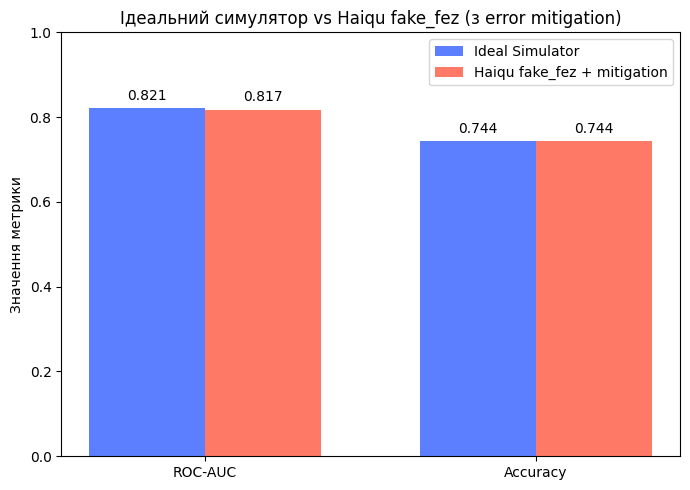

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
metrics = ["ROC-AUC", "Accuracy"]
ideal_vals = [auc_exact, acc_exact]
haiqu_vals = [auc_hw, acc_hw]

x = range(len(metrics))
width = 0.35
ax.bar([i - width/2 for i in x], ideal_vals, width, label="Ideal Simulator", color="#5B7FFF")
ax.bar([i + width/2 for i in x], haiqu_vals, width, label="Haiqu fake_fez + mitigation", color="#FF7A66")

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_ylabel("Значення метрики")
ax.set_title("Ідеальний симулятор vs Haiqu fake_fez (з error mitigation)")
ax.legend()

for i, (iv, hv) in enumerate(zip(ideal_vals, haiqu_vals)):
    ax.text(i - width/2, iv + 0.02, f"{iv:.3f}", ha="center", fontsize=10)
    ax.text(i + width/2, hv + 0.02, f"{hv:.3f}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("qnn_haiqu_comparison_chart.png", dpi=150, bbox_inches="tight")
plt.show()